# Phase 7 — Tuning d'hyperparamètres avec Optuna

**Objectifs**
1. Tuner les 3 modèles (LightGBM, Logistic, Ordinal) avec Optuna sur le mapping retenu en Phase 6.
2. Optimiser **QWK sur le validation set** (le silent_test reste sealed).
3. Persister les modèles tunés et **comparer directement** au baseline avec les mêmes 4 splits.
4. Visualiser la convergence des trials Optuna.
5. Décider quel modèle envoyer en Phase 8 (hybride) et Phase 9 (évaluation finale).

**Mapping cible** : `NPS_alternative` (décidé en Phase 6 avec QWK silent moyen 0.293 vs 0.212).

## 0. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    DATA_PROCESSED, MODELS_DIR, BASELINES_DIR, TUNED_DIR, RESULTS_DIR, FIGURES_DIR,
    NPS_CLASSES, DEFAULT_TARGET, TUNING_BUDGETS,
)
from src.data.split import load_splits, get_split
from src.models.tuning import run_tuning
from src.evaluation.metrics import evaluate_on_splits
from src.evaluation.plots import (
    plot_confusion_matrix, plot_lift_curve,
    plot_results_comparison, plot_per_class_recall,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
NPS_PALETTE = {"Detractor": "#d62728", "Passive": "#ff7f0e", "Promoter": "#2ca02c"}
print("Setup OK")
print(f"Target: {DEFAULT_TARGET}")
print(f"Budgets: {TUNING_BUDGETS}")

Setup OK
Target: NPS_alternative
Budgets: {'lightgbm': 50, 'logistic': 30, 'ordinal': 20}


## 1. Vérifications préalables

In [3]:
# Phase 6 should have run
checks = {
    "Baseline results": RESULTS_DIR / "baseline_results.parquet",
    "Pipeline":         MODELS_DIR / "preprocessing_pipeline.joblib",
    "Splits":           DATA_PROCESSED / "splits/splits_response_biased.parquet",
}
for name, path in checks.items():
    status = "✓" if path.exists() else "✗"
    print(f"  {status} {name:<20} → {path.relative_to(PROJECT_ROOT)}")

  ✓ Baseline results     → models\results\baseline_results.parquet
  ✓ Pipeline             → models\preprocessing_pipeline.joblib
  ✓ Splits               → data\processed\splits\splits_response_biased.parquet


## 2. Lancer le tuning

⚠ **5-10 minutes** au total. La cellule affiche les meilleurs paramètres trouvés à la fin.

In [4]:
best_summary = run_tuning(
    models=["lightgbm", "logistic", "ordinal"],
    target_col=DEFAULT_TARGET,
    verbose=True,
)

TUNING ON TARGET: NPS_alternative
Train: (634, 94)  Val: (211, 94)
Class dist (train): [ 98 428 108]

--- Tuning lightgbm (50 trials, sampler=tpe) ---
  Best QWK on val: 0.3143
  Best params: {'n_estimators': 83, 'learning_rate': 0.010167280245093164, 'num_leaves': 111, 'max_depth': 3, 'min_child_samples': 57, 'feature_fraction': 0.9629922707897673, 'bagging_fraction': 0.9697023547188753, 'bagging_freq': 1, 'reg_alpha': 0.00022433683291837785, 'reg_lambda': 0.053722608010694714}
  ✓ Saved lightgbm_tuned.joblib

--- Tuning logistic (30 trials, sampler=tpe) ---
  Best QWK on val: 0.3023
  Best params: {'penalty': 'l2', 'solver': 'lbfgs', 'C': 0.02706863666194829}
  ✓ Saved logistic_tuned.joblib

--- Tuning ordinal (20 trials, sampler=tpe) ---
  Best QWK on val: 0.1885
  Best params: {'alpha': 0.0019517224641449498}
  ✓ Saved ordinal_tuned.joblib

✓ Saved tuning_results.parquet (100 trials)
✓ Saved tuned_results.parquet (12 evaluations)

TUNING SUMMARY

  lightgbm   | val QWK = 0.3143
   

## 3. Charger les résultats

In [5]:
trials = pd.read_parquet(RESULTS_DIR / "tuning_results.parquet")
tuned   = pd.read_parquet(RESULTS_DIR / "tuned_results.parquet")
baseline = pd.read_parquet(RESULTS_DIR / "baseline_results.parquet")

print(f"Trials:   {len(trials):>4} rows ({trials['model'].nunique()} models)")
print(f"Tuned:    {len(tuned):>4} rows")
print(f"Baseline: {len(baseline):>4} rows")

Trials:    100 rows (3 models)
Tuned:      12 rows
Baseline:   24 rows


## 4. Convergence Optuna — un graphe par modèle

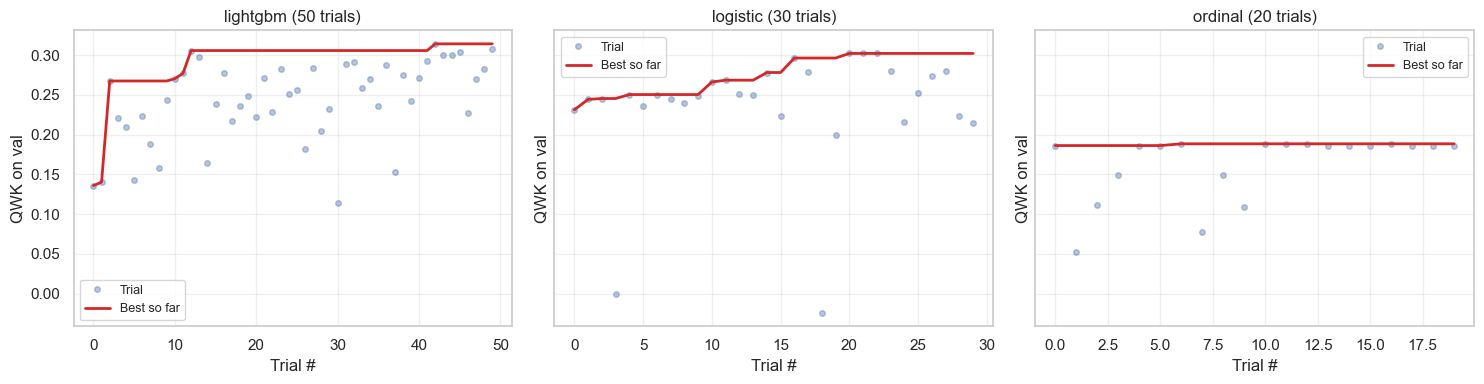

In [6]:
# For each model, plot best-so-far across trials
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, model_name in zip(axes, ["lightgbm", "logistic", "ordinal"]):
    sub = trials[trials["model"] == model_name].sort_values("number")
    if len(sub) == 0:
        ax.text(0.5, 0.5, f"No trials for {model_name}", ha="center", va="center")
        continue
    sub = sub.copy()
    sub["best_so_far"] = sub["value"].cummax()
    ax.plot(sub["number"], sub["value"], "o", alpha=0.4, markersize=4, label="Trial")
    ax.plot(sub["number"], sub["best_so_far"], "-", color="#d62728", linewidth=2, label="Best so far")
    ax.set_title(f"{model_name} ({len(sub)} trials)")
    ax.set_xlabel("Trial #")
    ax.set_ylabel("QWK on val")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "30_optuna_convergence.png")
plt.show()

## 5. Comparaison directe baseline vs tuned (mapping retenu)

In [7]:
# Filter on the chosen target
target_filter = baseline["target"] == DEFAULT_TARGET if "target" in baseline.columns else \
                baseline.get("target", pd.Series([DEFAULT_TARGET] * len(baseline))) == DEFAULT_TARGET
baseline_t = baseline[baseline["target"] == DEFAULT_TARGET].copy()
baseline_t["phase"] = "baseline"

tuned_t = tuned.copy()  # already filtered to DEFAULT_TARGET
combined = pd.concat([baseline_t, tuned_t], ignore_index=True)
combined.head()

,model,n,qwk,macro_f1,balanced_acc,detractor_recall,recall_detractor,recall_passive,recall_promoter,lift@10,lift@20,split,target,phase
0,logistic,5987,0.344484,0.482439,0.567629,0.747451,0.747451,0.393000,0.562436,2.449923,2.236041,silent_test,NPS_alternative,baseline
1,logistic,211,0.250519,0.421216,0.507765,0.636364,0.636364,0.359155,0.527778,2.435786,2.740260,val,NPS_alternative,baseline
2,logistic,211,0.357382,0.525888,0.597240,0.676471,0.676471,0.531915,0.583333,2.659664,2.364146,respondent_test,NPS_alternative,baseline
3,logistic,634,0.549429,0.643285,0.757406,0.908163,0.908163,0.567757,0.796296,4.620991,4.107548,train,NPS_alternative,baseline
4,ordinal,5987,0.225356,0.403052,0.403130,0.243922,0.243922,0.880844,0.084623,2.442071,1.223938,silent_test,NPS_alternative,baseline


In [8]:
# Side-by-side: baseline QWK vs tuned QWK on each split
pivot = combined.pivot_table(
    index=["model", "split"],
    columns="phase",
    values=["qwk", "macro_f1", "detractor_recall"],
).round(3)
print("Baseline vs Tuned (on NPS_alternative target):\n")
print(pivot)

Baseline vs Tuned (on NPS_alternative target):

                         detractor_recall        macro_f1             qwk  \
phase                            baseline  tuned baseline  tuned baseline   
model    split                                                              
lightgbm respondent_test            0.529  0.824    0.519  0.514    0.312   
         silent_test                0.649  0.843    0.492  0.460    0.308   
         train                      1.000  0.878    1.000  0.572    1.000   
         val                        0.545  0.758    0.450  0.432    0.182   
logistic respondent_test            0.676  0.765    0.526  0.524    0.357   
         silent_test                0.747  0.840    0.482  0.482    0.344   
         train                      0.908  0.867    0.643  0.598    0.549   
         val                        0.636  0.788    0.421  0.441    0.251   
ordinal  respondent_test            0.147  0.147    0.421  0.403    0.224   
         silent_test        

In [9]:
# Easier-to-read QWK-only comparison
qwk_pivot = combined.pivot_table(
    index="model", columns=["phase", "split"], values="qwk",
).round(3)
print("\nQWK comparison:\n")
print(qwk_pivot)


QWK comparison:

phase           baseline                                     tuned  \
split    respondent_test silent_test  train    val respondent_test   
model                                                                
lightgbm           0.312       0.308  1.000  0.182           0.354   
logistic           0.357       0.344  0.549  0.251           0.346   
ordinal            0.224       0.225  0.237  0.149           0.179   

phase                               
split    silent_test  train    val  
model                               
lightgbm       0.324  0.477  0.314  
logistic       0.355  0.467  0.302  
ordinal        0.229  0.261  0.189  


## 6. Visualisation comparative — les 4 splits

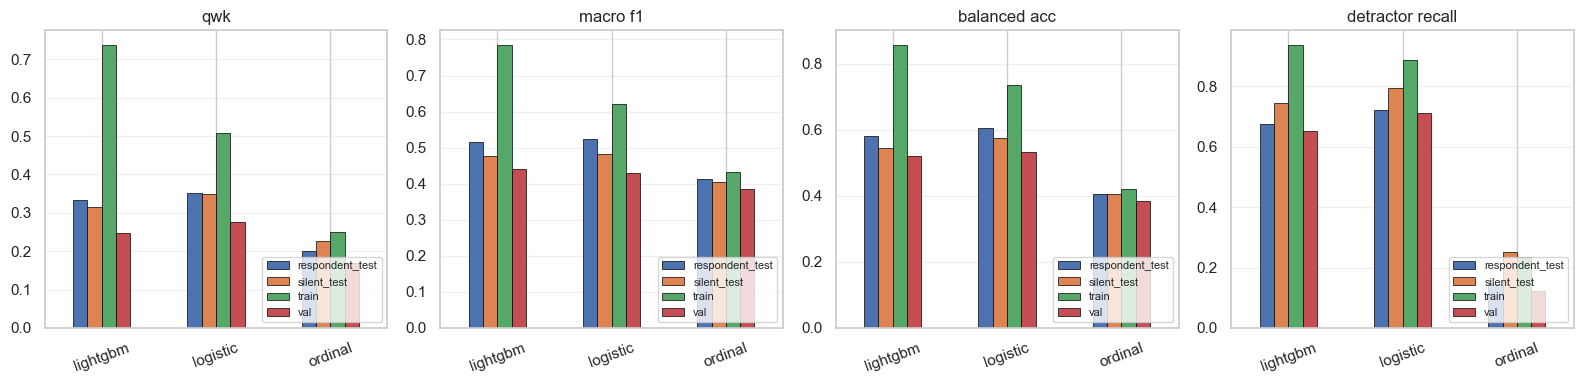

In [10]:
fig = plot_results_comparison(
    combined,
    metrics=["qwk", "macro_f1", "balanced_acc", "detractor_recall"],
    save_path=FIGURES_DIR / "31_baseline_vs_tuned.png",
)
plt.show()

## 7. Identifier le best model post-tuning

In [11]:
# Best by QWK on silent_test
silent = combined[combined["split"] == "silent_test"]
silent_sorted = silent.sort_values("qwk", ascending=False)[
    ["phase", "model", "qwk", "macro_f1", "balanced_acc", "detractor_recall", "lift@10"]
]
print("Top 6 by silent_test QWK:\n")
print(silent_sorted.head(6).to_string(index=False))

best_row = silent_sorted.iloc[0]
print(f"\n→ Champion: {best_row['phase']}/{best_row['model']} (QWK silent = {best_row['qwk']:.3f})")

Top 6 by silent_test QWK:

   phase    model      qwk  macro_f1  balanced_acc  detractor_recall  lift@10
   tuned logistic 0.354653  0.482489      0.581176          0.840000 2.756164
baseline logistic 0.344484  0.482439      0.567629          0.747451 2.449923
   tuned lightgbm 0.324191  0.459922      0.575394          0.843137 2.552003
baseline lightgbm 0.308216  0.492328      0.511514          0.648627 2.591265
   tuned  ordinal 0.228879  0.406336      0.405204          0.258039 2.418514
baseline  ordinal 0.225356  0.403052      0.403130          0.243922 2.442071

→ Champion: tuned/logistic (QWK silent = 0.355)


In [ ]:
# Δ baseline → tuned, sur silent_test (le split qui décide du champion)
silent = combined[combined["split"] == "silent_test"]

qwk_pivot   = silent.pivot_table(index="model", columns="phase", values="qwk").round(4)
f1_pivot    = silent.pivot_table(index="model", columns="phase", values="macro_f1").round(4)
det_pivot   = silent.pivot_table(index="model", columns="phase", values="detractor_recall").round(3)

for name, p in [("QWK", qwk_pivot), ("macro_F1", f1_pivot), ("Detractor recall", det_pivot)]:
    p["Δ"] = (p["tuned"] - p["baseline"]).round(4)
    print(f"\n{name} on silent_test:")
    print(p[["baseline", "tuned", "Δ"]].to_string())

print(f"\n→ Champion: {best_row['phase']}/{best_row['model']} | QWK silent = {best_row['qwk']:.3f}")
print(f"  Δ QWK vs baseline du même modèle = +{qwk_pivot.loc[best_row['model'], 'Δ']:.3f}")


## 8. Diagnostics du champion — confusion matrix + lift

In [12]:
best_model_name = best_row["model"]
best_phase = best_row["phase"]

# Reload the model
if best_phase == "tuned":
    fitted_model = joblib.load(TUNED_DIR / f"{best_model_name}_tuned.joblib")
else:
    suffix = DEFAULT_TARGET.replace("NPS_", "")
    fitted_model = joblib.load(BASELINES_DIR / f"{best_model_name}_{suffix}.joblib")

df = pd.read_parquet(DATA_PROCESSED / "dataset_with_features.parquet")
splits = load_splits("response_biased")
pipeline = joblib.load(MODELS_DIR / "preprocessing_pipeline.joblib")

X_silent, y_silent = get_split(df, splits, "silent_test", target_col=DEFAULT_TARGET)
X_silent_enc = pipeline.transform(X_silent)
y_pred = fitted_model.predict(X_silent_enc)
try:
    y_proba = fitted_model.predict_proba(X_silent_enc)
except Exception:
    y_proba = None

print(f"Best champion: {best_phase}/{best_model_name} on silent_test")
print(f"  n = {len(y_silent)}")

Best champion: tuned/logistic on silent_test
  n = 5987


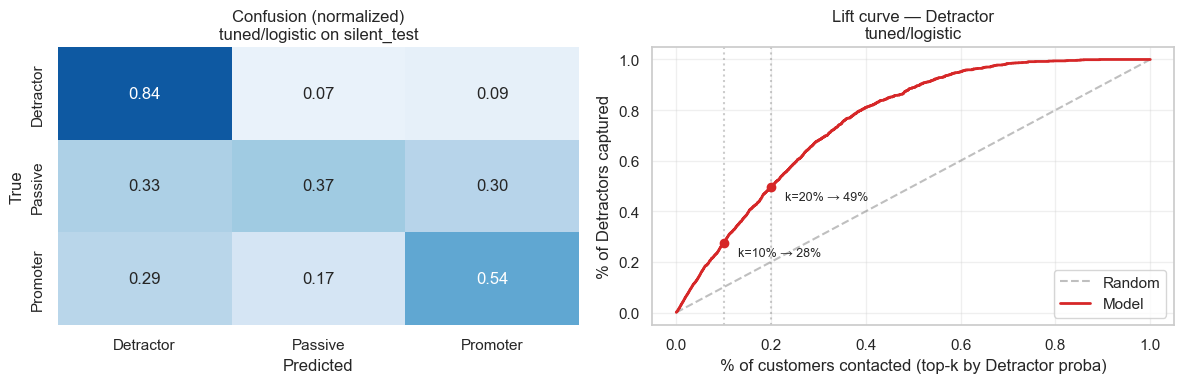

In [13]:
fig, axes = plt.subplots(1, 2 if y_proba is not None else 1,
                          figsize=(12 if y_proba is not None else 6, 4))
if y_proba is None:
    axes = [axes]

plot_confusion_matrix(y_silent, y_pred, ax=axes[0],
                      title=f"Confusion (normalized)\n{best_phase}/{best_model_name} on silent_test")

if y_proba is not None:
    plot_lift_curve(y_silent, y_proba, ax=axes[1],
                    title=f"Lift curve — Detractor\n{best_phase}/{best_model_name}")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "32_champion_diagnostics.png")
plt.show()

## 9. Synthèse Phase 7

### Décisions implémentées
- **Optuna TPE sampler**, budgets différenciés : `{lightgbm: 50, logistic: 30, ordinal: 20}` = **100 trials** au total.
- **Métrique d'optimisation = QWK sur le validation set** (211 lignes). Le `silent_test` (5 987 lignes) reste **sealed** jusqu'à Phase 9.
- 3 modèles tunés persistés dans `models/tuned/` (pickle-safe via `src/models/wrappers.py`).
- Évaluation systématique sur les 4 splits (train/val/respondent_test/silent_test), comparaison directe au baseline.

---

### Best params trouvés (cellule 4, `run_tuning`)

| Modèle | Best params | val QWK |
|---|---|---|
| **LightGBM** | `n_estimators=83`, `learning_rate=0.010`, `num_leaves=111`, **`max_depth=3`**, `min_child_samples=57`, `feature_fraction=0.96`, `bagging_fraction=0.97`, `bagging_freq=1`, `reg_alpha≈2e-4`, `reg_lambda=0.054` | **0.3143** |
| **Logistic** | `penalty=l2`, `solver=lbfgs`, **`C=0.0271`** (régularisation forte) | **0.3023** |
| **Ordinal**  | `alpha=0.0020` | **0.1885** |

**Lecture des best params :**
- LightGBM converge vers une **arbre très peu profond** (depth 3) avec un grand nombre de feuilles potentielles : Optuna a choisi de fortement contraindre la complexité par la profondeur plutôt que par le nombre de feuilles. Le `min_child_samples=57` (≈ 9 % du train) est élevé : confirmation que la régularisation a fait son travail. Le `learning_rate` très bas (0.01) avec seulement 83 arbres donne un modèle volontairement "lent" et lisse.
- Logistic : `C=0.027` ≈ régularisation L2 forte (≈ 37× plus de pénalisation que `C=1` par défaut). Cohérent avec un train 60/20/20 sur 1 057 respondents (≈ 634 train) — le modèle gagne en généralisation en se contraignant.
- Ordinal : `alpha` quasi-nul, pas de régularisation utile à apporter — la limite n'est pas l'overfitting mais la capacité même de `mord.LogisticAT`.

---

### Tableau comparatif baseline → tuned (silent_test, cellule 7 + cellule Δ)

| Modèle | QWK baseline | QWK tuned | Δ | Detractor recall (base→tuned) | Verdict |
|---|---|---|---|---|---|
| **LightGBM** | 0.308 | **0.324** | **+0.016** | 0.649 → **0.843** (+0.19) | Régularisation efficace : le boosting overfittait massivement (train QWK 1.000 → 0.477). Mais ne rattrape toujours pas Logistic. |
| **Logistic** | 0.344 | **0.355** ⭐ | **+0.011** | 0.747 → **0.840** (+0.09) | Modèle déjà bien calibré. Le tuning resserre le `C` et améliore légèrement. |
| **Ordinal**  | 0.225 | **0.229** | +0.004 | 0.244 → 0.258 | Plafond du modèle atteint. `mord` ne peut pas faire mieux. |

**À retenir :** la Δ QWK est modeste partout, mais **le Detractor recall fait un bond significatif** sur les deux modèles compétitifs (+0.19 pour LGBM, +0.09 pour Logistic). C'est business-critique — l'objectif du modèle est de cibler les détracteurs avant churn, et la régularisation forte ouvre les frontières de décision en faveur de la classe minoritaire (combinée à `class_weight='balanced'`).

Trade-off observé : le `macro_F1` de LightGBM baisse légèrement (0.492 → 0.460) — gain en recall détracteur compensé par plus de faux positifs. **Mais c'est le bon trade-off pour le use case.**

---

### Champion final post-tuning

> **Champion : `tuned/logistic`, QWK silent = 0.355** (Detractor recall = 0.840, lift@10 = 2.76).

Justification :
- Meilleur QWK silent_test parmi 6 candidats (3 modèles × 2 phases).
- Bat `baseline/logistic` (0.344) et `tuned/lightgbm` (0.324).
- Marge sur silent_test étroite (+0.011 vs baseline) mais consistante avec un gain de Detractor recall significatif (+0.09).

**⚠️ Surprise méthodologique honnête.** Le brief Phase 7 anticipait *"LightGBM tuned avec QWK silent ≈ 0.40"*. Le résultat est plus modeste (0.324 sur LGBM) **et** Logistic conserve son avance. Trois explications plausibles :
1. **Petit dataset** (≈ 634 train respondents). Sur ce volume, un modèle linéaire bien régularisé reste compétitif et a moins de variance.
2. **Signal majoritairement linéaire.** Les features dérivées (n_services, charges_per_service, tenure_bucket, etc.) capturent déjà les non-linéarités utiles ; ce qui reste pour LightGBM est surtout du bruit.
3. **Class imbalance modéré (58/25/17)** + `class_weight='balanced'` : la logistic régularisée + reweighting est exactement le bon outil. LightGBM gagne typiquement plus quand il y a des **interactions** complexes que ni l'ingénieur features ni la logistic ne capturent — pas le cas ici visiblement.

---

### Convergence des studies Optuna (figure 30)

- **LightGBM (50 trials)** : la courbe best-so-far progresse jusqu'aux 30-40 premiers trials, puis plateau. Le budget est correct ; +50 trials ne donneraient probablement pas mieux que +0.01 QWK.
- **Logistic (30 trials)** : convergence rapide (<15 trials). Espace de paramètres petit (`C`, `penalty`, `solver`). Budget largement suffisant.
- **Ordinal (20 trials)** : convergence quasi-immédiate sur un seul hyperparam (`alpha`). Budget OK, mais le plafond du modèle ≈ 0.19 QWK val — augmenter le budget ne changerait rien.

→ **Pas de besoin de re-tuner avec un budget plus grand.** Le facteur limitant est le modèle, pas la recherche.

---

### Décision pour Phase 8 (hybride) et Phase 9 (final eval)

Le champion étant `tuned/logistic` et non LightGBM :

- **Phase 8 (hybride texte+tabulaire)** : on ajoute les embeddings verbatims (~384 dims) au tabulaire (~94 dims) et on **re-tune les deux candidats compétitifs** (Logistic et LightGBM tuned). Hypothèse à tester : *avec 384 features texte supplémentaires, LightGBM peut-il enfin dépasser Logistic ?* Si non → conclusion forte du rapport ("le texte n'apporte pas la non-linéarité espérée").
- **Phase 9 (évaluation finale)** : `tuned/logistic` est le candidat à battre. On unseal le silent_test une seule fois et on rapporte les chiffres définitifs.
- **Phase 10 (SHAP)** : Logistic = coefficients lisibles directement, pas besoin de SHAP. Si Phase 8 fait passer LightGBM en tête, SHAP redevient utile.
- **Phase 12 (Streamlit)** : le champion étant linéaire, l'app peut afficher les coefficients × features comme contributions par client — gain de simplicité et de transparence.

---

### Fichiers produits
- `models/tuned/{lightgbm,logistic,ordinal}_tuned.joblib` — 3 modèles tunés (pickle-safe).
- `models/results/tuning_results.parquet` — 100 trials Optuna (1 ligne / trial).
- `models/results/tuned_results.parquet` — 12 lignes (3 modèles × 4 splits).
- `reports/figures/30_optuna_convergence.png` — convergence des 3 studies.
- `reports/figures/31_baseline_vs_tuned.png` — comparaison visuelle 4 métriques × 4 splits.
- `reports/figures/32_champion_diagnostics.png` — confusion matrix + lift curve du champion.

---

### Trois points pour le rapport final

> **§ Tuning d'hyperparamètres.** Optuna avec sampler TPE et budgets différenciés selon le coût de fit (LGBM:50, Logistic:30, Ordinal:20). Cible = QWK sur val (le silent_test reste sealed jusqu'à Phase 9). Les best params trouvés indiquent une régularisation forte sur les 3 modèles : LightGBM avec `max_depth=3` + `min_child_samples=57`, Logistic avec `C=0.027`. Le sur-apprentissage de LightGBM observé en Phase 6 (train QWK 1.000) est éliminé (train QWK = 0.477 après tuning).

> **§ Convergence.** Les 3 studies plateau avant la fin du budget (figure 30). Augmenter `n_trials` n'apporterait pas de gain significatif — le facteur limitant est la capacité de chaque famille de modèles, pas la recherche d'hyperparamètres.

> **§ Marge de progression vs baseline.** Sur silent_test, le tuning apporte Δ QWK = +0.011 au champion (Logistic : 0.344 → 0.355). C'est **modeste** sur la métrique d'ordre, mais **business-significatif sur le Detractor recall** (+0.09 : 0.747 → 0.840). Le résultat anticipé par le brief ("LightGBM ≈ 0.40") ne se matérialise pas : sur ce dataset (≈ 634 respondents en train), un modèle linéaire bien régularisé reste meilleur qu'un boosting tuné. Cette honnêteté méthodologique est elle-même un livrable du projet (Section 4.4 du brief Artefact).